we need to do these things -

* EDA
* Define an Instructor Effectiveness Score
* Build ML model (Linear refression and Logistic regrezssion) to predict effectiveness tier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('instructor_effectiveness_dataset_2000_rows.xlsx')
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [5]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [6]:
df.duplicated().sum()

np.int64(0)

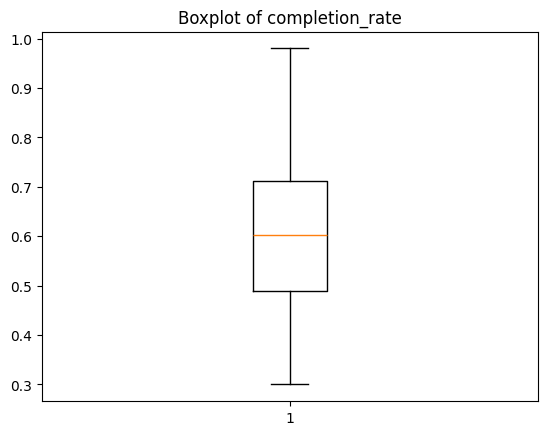

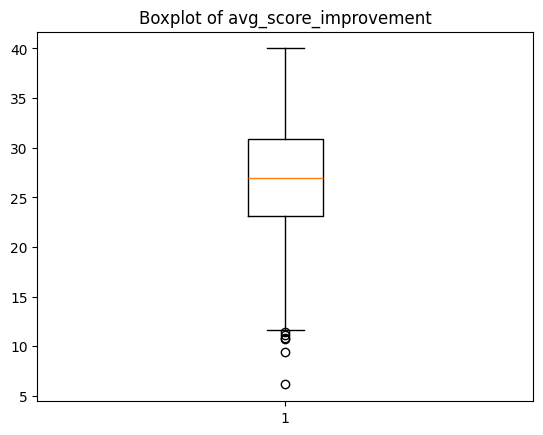

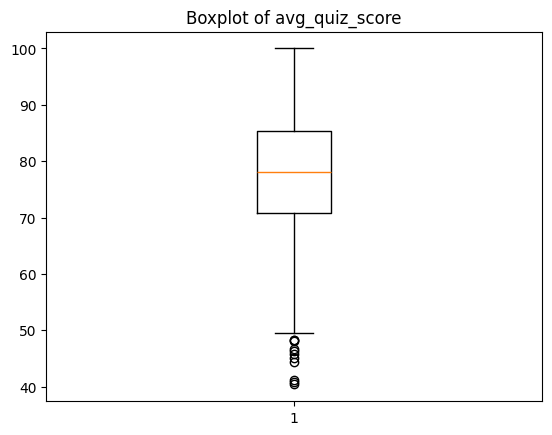

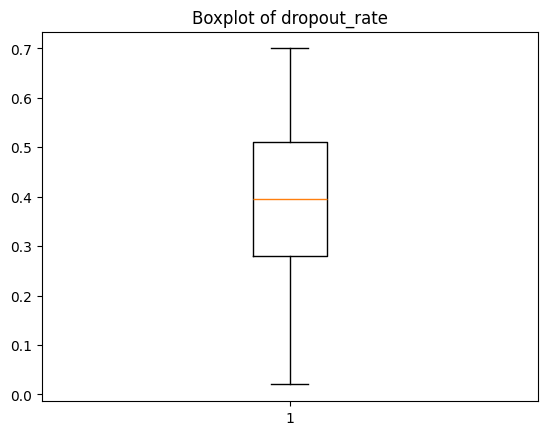

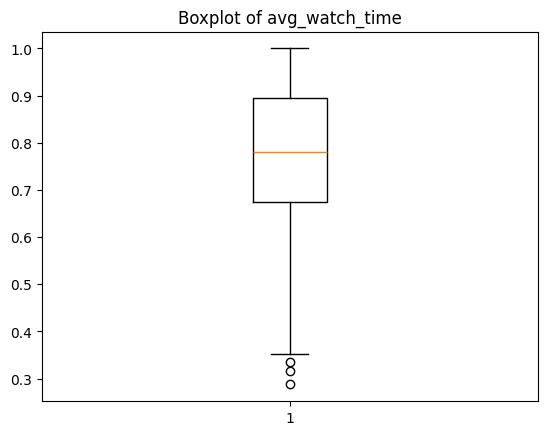

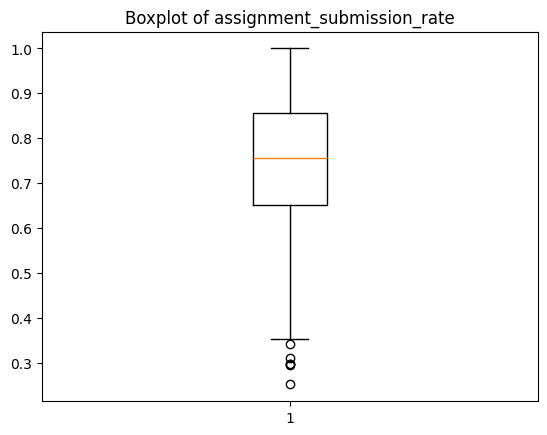

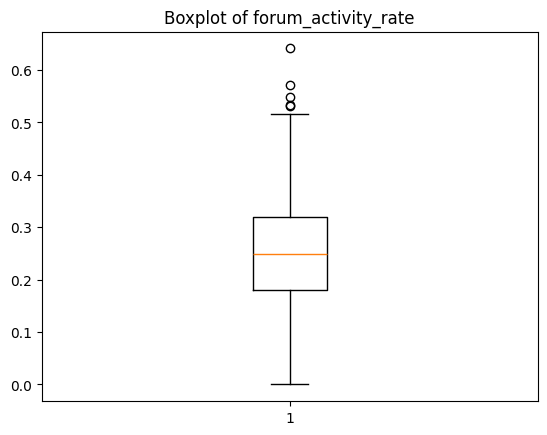

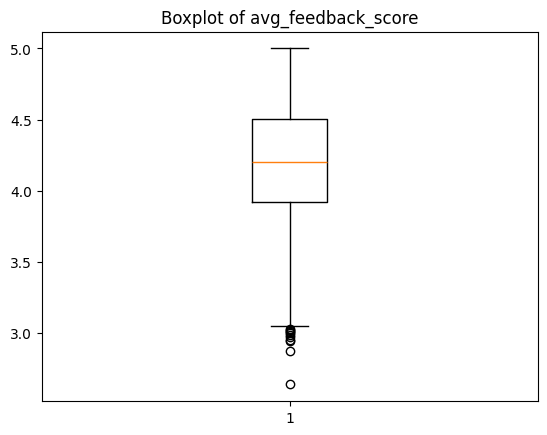

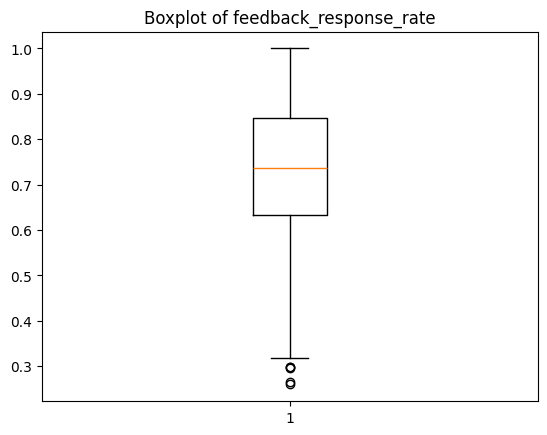

In [7]:
from matplotlib import pyplot as plt
numeric_df = df.select_dtypes(include=['number'])

for col in numeric_df.columns:
    plt.figure()
    plt.boxplot(numeric_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [8]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_rows = len(df)
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed_rows = initial_rows - len(df_cleaned)
    print(f"Removed {removed_rows} outliers from '{column}'.")
    return df_cleaned
columns_with_outliers = ['avg_score_improvement', 'avg_quiz_score', 'avg_feedback_score']
initial_shape = df.shape
print(f"Initial DataFrame shape: {initial_shape}")
df_cleaned = df.copy()
for col in columns_with_outliers:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)
print(f"DataFrame shape after outlier removal: {df_cleaned.shape}")

Initial DataFrame shape: (2000, 12)
Removed 6 outliers from 'avg_score_improvement'.
Removed 11 outliers from 'avg_quiz_score'.
Removed 11 outliers from 'avg_feedback_score'.
DataFrame shape after outlier removal: (1972, 12)


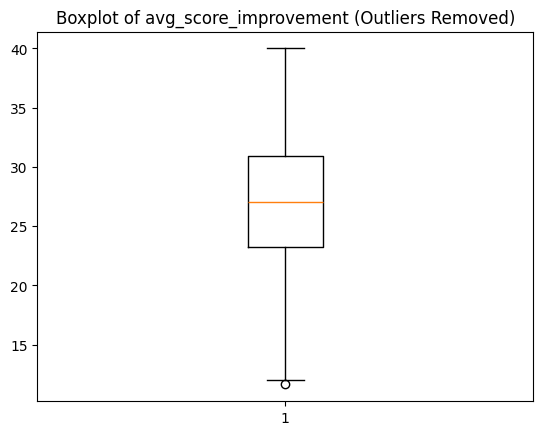

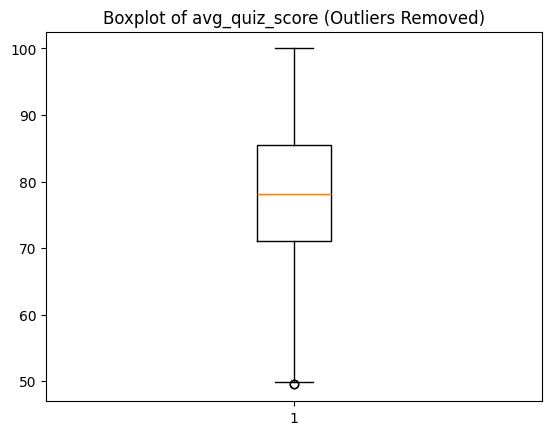

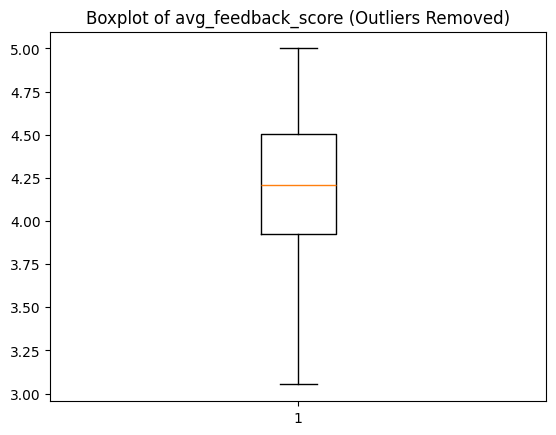

In [9]:
import matplotlib.pyplot as plt

# Re-plot boxplots for the cleaned data
for col in columns_with_outliers:
    plt.figure()
    plt.boxplot(df_cleaned[col])
    plt.title(f'Boxplot of {col} (Outliers Removed)')
    plt.show()

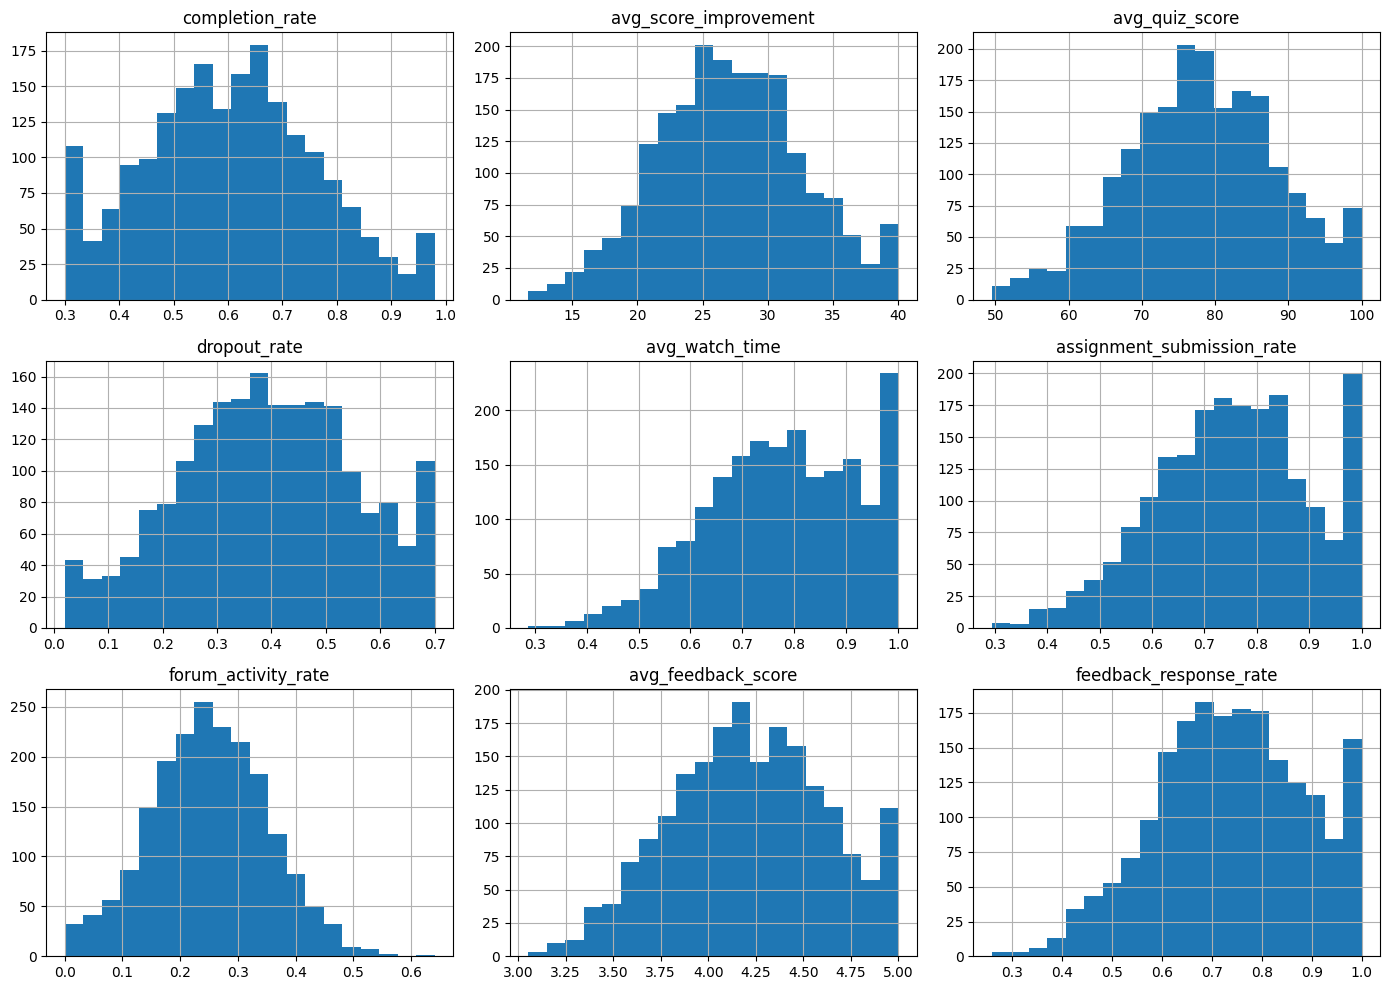

In [10]:
num_cols = ['completion_rate','avg_score_improvement','avg_quiz_score','dropout_rate','avg_watch_time','assignment_submission_rate','forum_activity_rate','avg_feedback_score','feedback_response_rate']
df_cleaned[num_cols].hist(bins=20, figsize=(14,10))
plt.tight_layout()
plt.show()

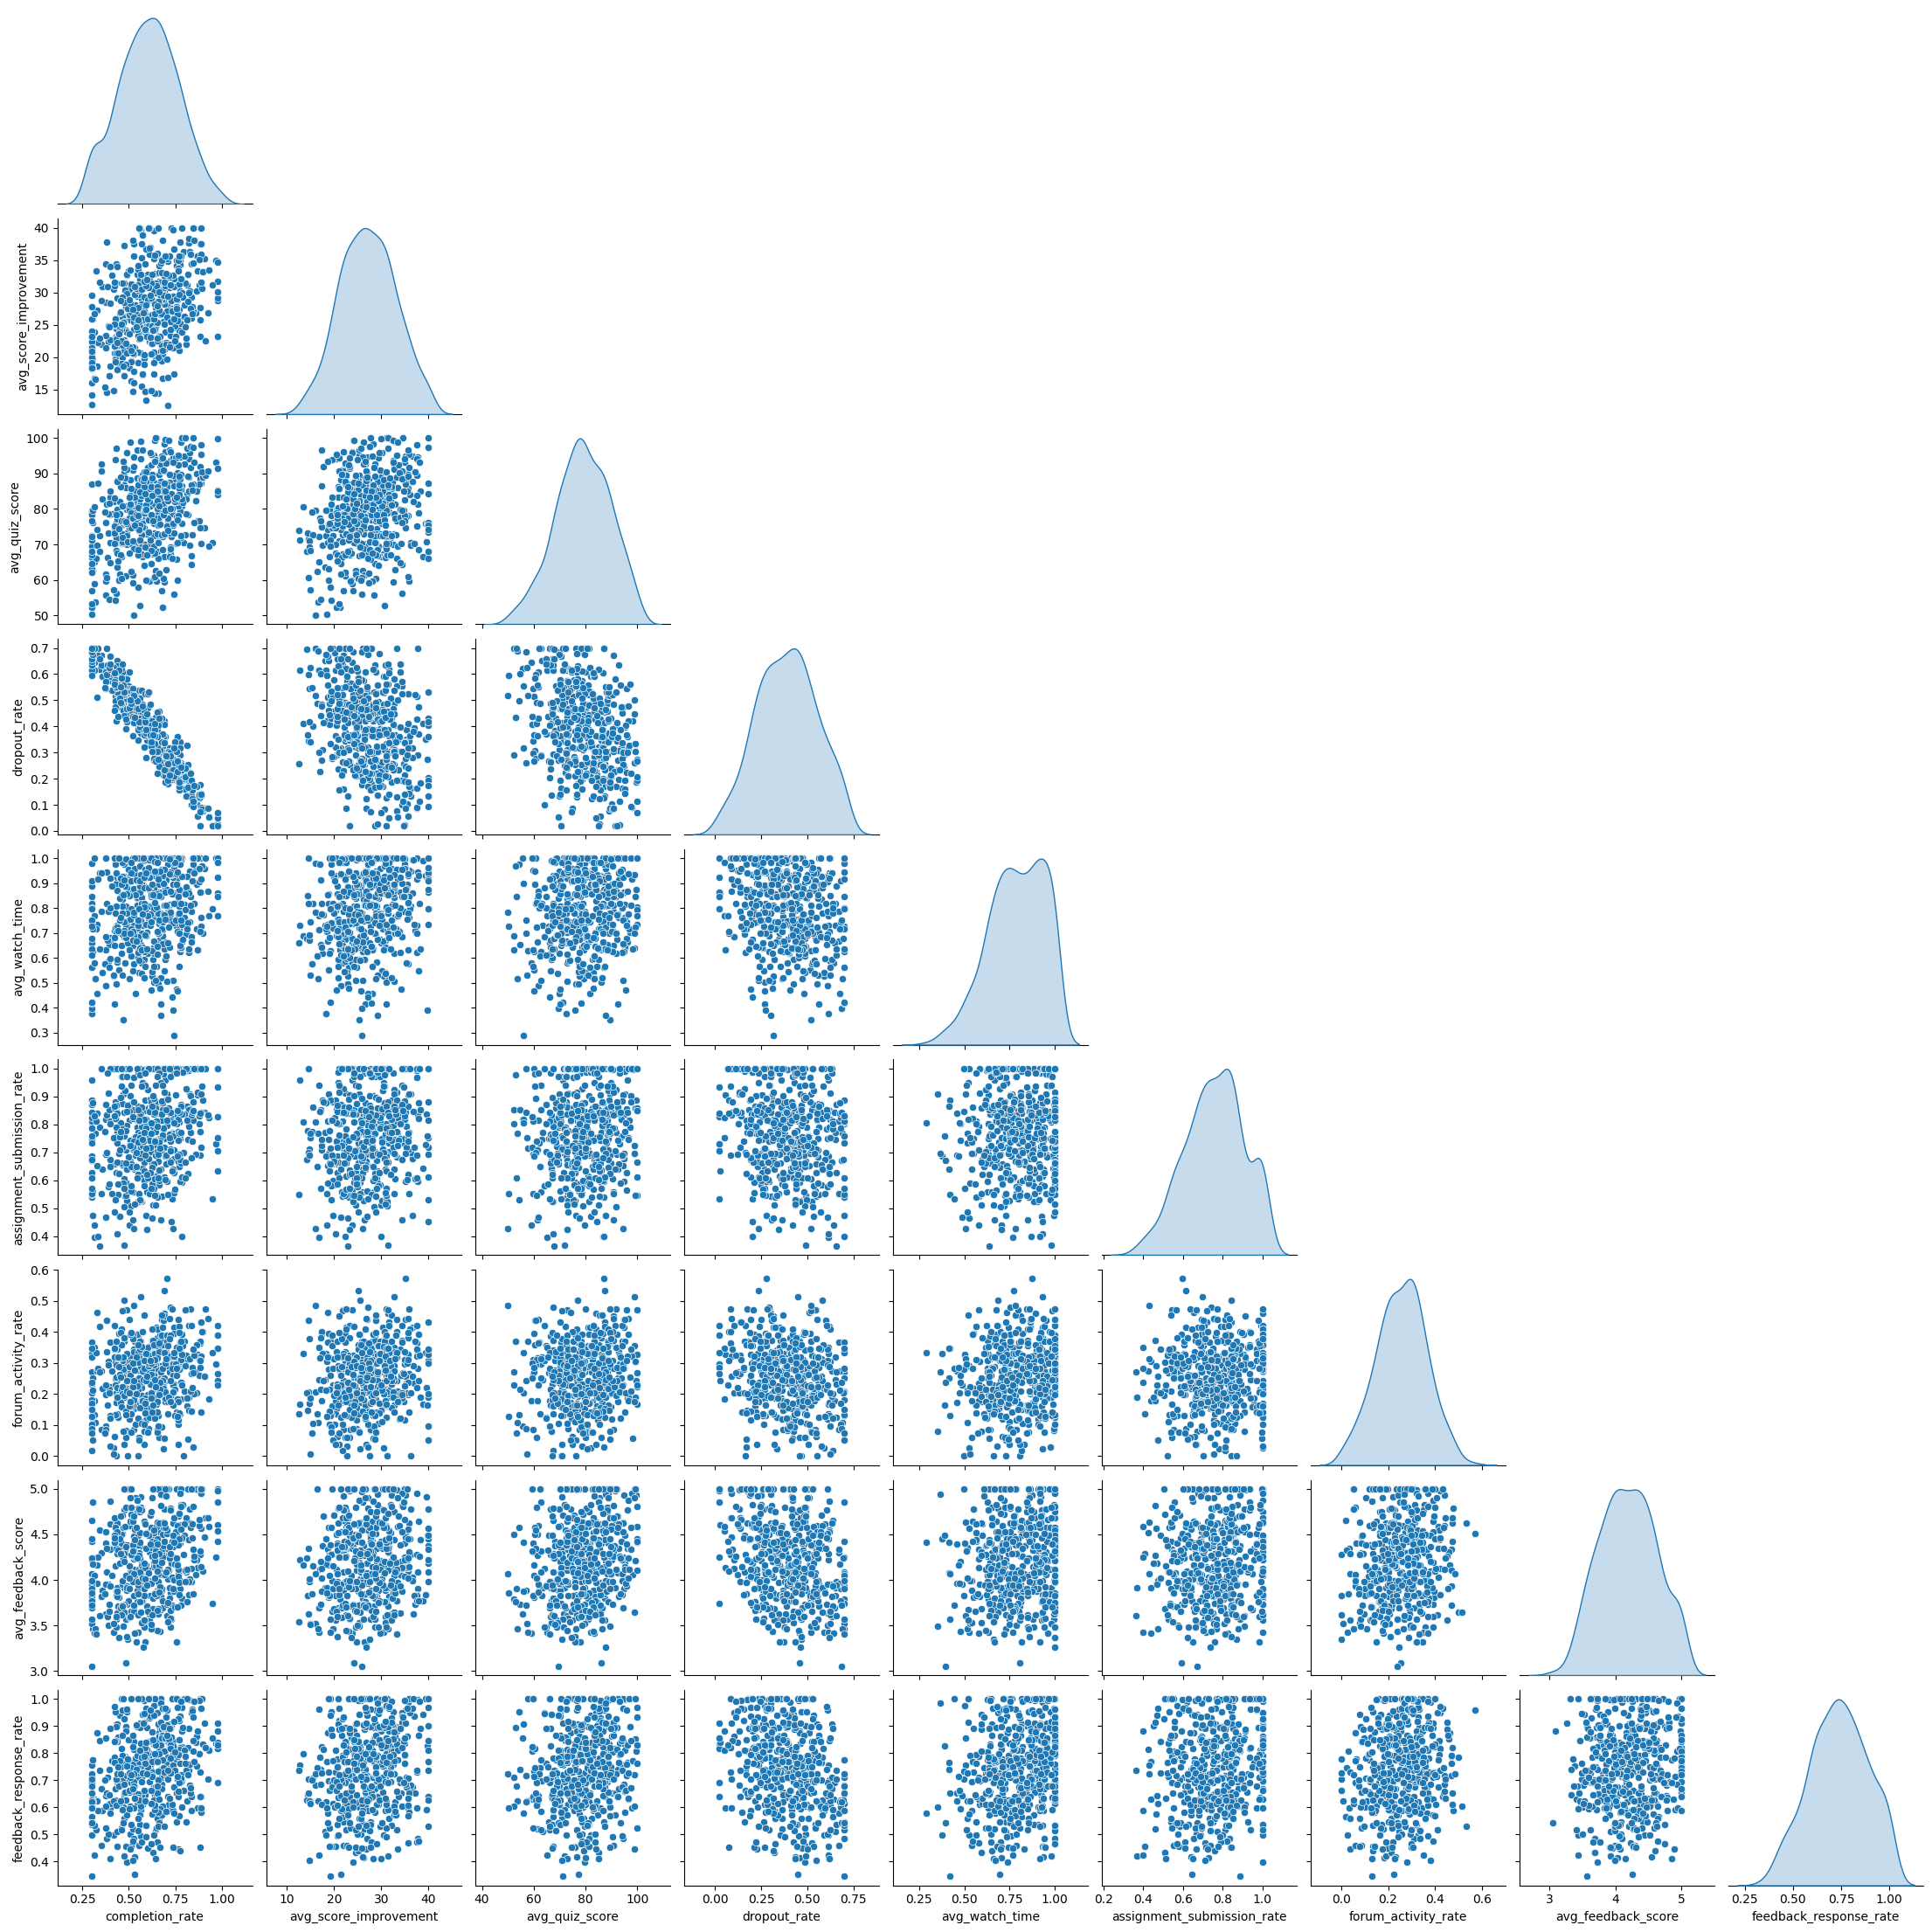

In [11]:
sns.pairplot(df_cleaned[num_cols].sample(min(500, len(df))), diag_kind='kde', corner=True)
plt.show()

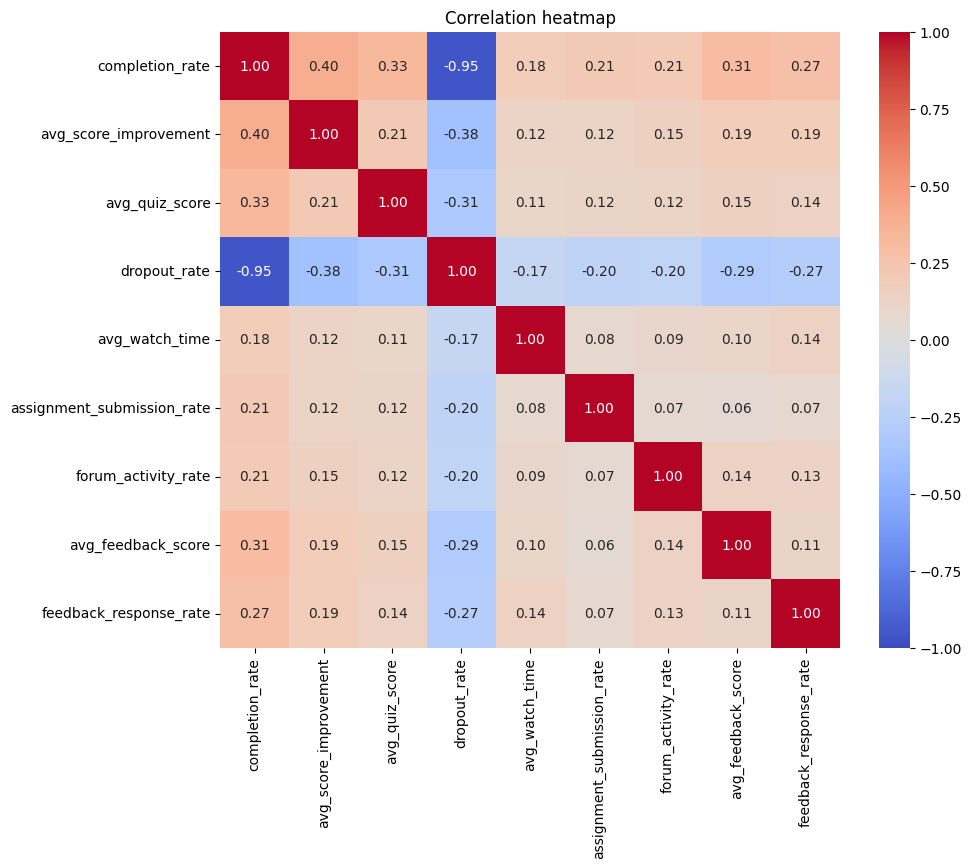

In [12]:
plt.figure(figsize=(10,8))
corr = df_cleaned[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.show()

In [13]:
df_cleaned = df_cleaned.drop(columns=['batch_id', 'instructor_id', 'course_id'])
display(df_cleaned.head())

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_cleaned['avg_score_improvement'] = scaler.fit_transform(df_cleaned[['avg_score_improvement']])
df_cleaned['avg_quiz_score'] = scaler.fit_transform(df_cleaned[['avg_quiz_score']])

display(df_cleaned.head())

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.300000,0.091366,0.476178,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,0.657220,0.396141,0.550747,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,0.300000,0.156993,0.595328,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,0.639507,0.445129,0.986046,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,0.527302,0.685590,0.987989,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


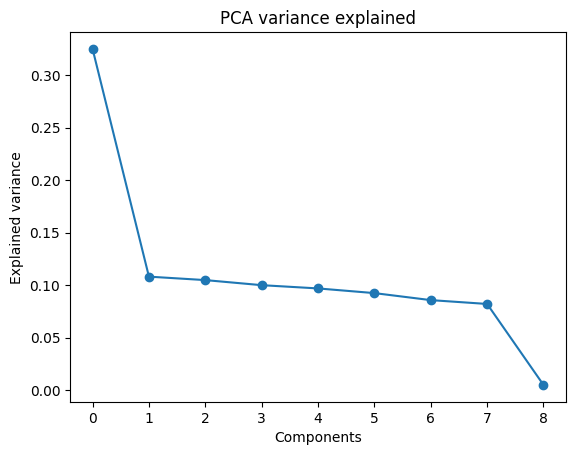

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = df[num_cols]
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker="o")
plt.title("PCA variance explained")
plt.xlabel("Components")
plt.ylabel("Explained variance")
plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Define positive and negative contributors
positive_contributors = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]
negative_contributors = ['dropout_rate']

all_contributors = positive_contributors + negative_contributors
scaler = MinMaxScaler()
df_cleaned_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned[all_contributors]), columns=all_contributors,index=df_cleaned.index)

# Invert negative contributors (dropout_rate: lower is better, so invert scaled value)
df_cleaned_scaled['dropout_rate'] = 1 - df_cleaned_scaled['dropout_rate']

# Calculate the Instructor Effectiveness Score (IFS) by summing scaled features
df_cleaned['instructor_effectiveness_score'] = df_cleaned_scaled[all_contributors].sum(axis=1)

display(df_cleaned[['instructor_effectiveness_score']].head())
display(df_cleaned['instructor_effectiveness_score'].describe())

,instructor_effectiveness_score
0,2.937072
1,5.243937
2,3.579373
3,5.678306
4,5.654180


,instructor_effectiveness_score
count,1972.000000
mean,4.985991
std,1.025341
min,1.970438
25%,4.279062
50%,5.003064
75%,5.655212
max,8.180818


In [17]:
# Define tiers for Instructor Effectiveness Score
df_cleaned['effectiveness_tier'] = pd.qcut(df_cleaned['instructor_effectiveness_score'],q=3,labels=['Low', 'Medium', 'High'])
display(df_cleaned[['instructor_effectiveness_score', 'effectiveness_tier']].head())
print("Distribution of Effectiveness Tiers:")
display(df_cleaned['effectiveness_tier'].value_counts())

,instructor_effectiveness_score,effectiveness_tier
0,2.937072,Low
1,5.243937,Medium
2,3.579373,Low
3,5.678306,High
4,5.654180,High


Distribution of Effectiveness Tiers:


,count
effectiveness_tier,
Low,658
Medium,657
High,657


Linear regression to predict effectiveness score

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of df_cleaned as df_processed
df_processed = df_cleaned.copy()

# Define features (X) and target (y)
X = df_processed[[
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]]
y = df_processed['instructor_effectiveness_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evalutation

In [20]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Linear Regression Model Performance:
Mean Squared Error: 0.0000
R-squared: 1.0000


In [21]:
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")


Model Coefficients:
completion_rate: 1.4706
avg_score_improvement: 1.0000
avg_quiz_score: 1.0000
dropout_rate: -1.4706
avg_watch_time: 1.4034
assignment_submission_rate: 1.4160
forum_activity_rate: 1.5598
avg_feedback_score: 0.5136
feedback_response_rate: 1.3512


/tmp/ipykernel_397/2401613811.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


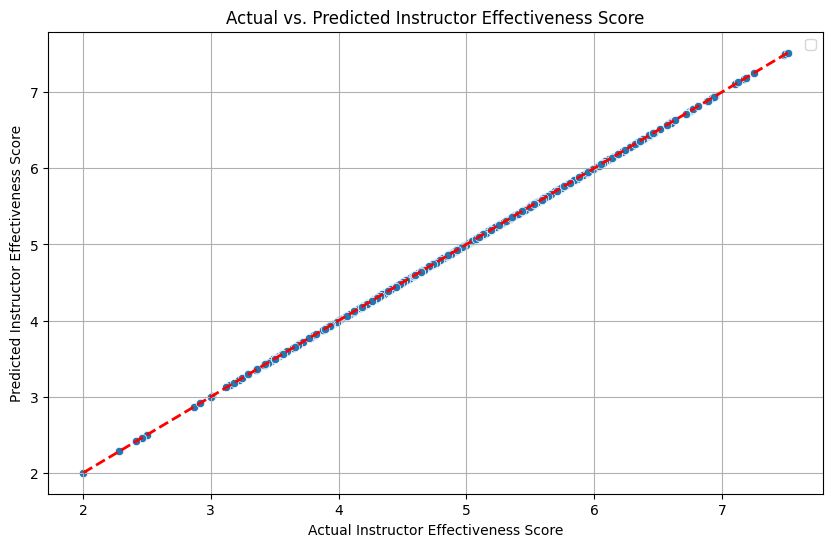

In [22]:
# Actual vs. Predicted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Instructor Effectiveness Score")
plt.ylabel("Predicted Instructor Effectiveness Score")
plt.title("Actual vs. Predicted Instructor Effectiveness Score")
plt.grid(True)
plt.legend()
plt.show()

Logistic Regression for Low, Medium, High classigication
\


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_processed = df_cleaned.copy()
tier_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['effectiveness_tier_encoded'] = df_processed['effectiveness_tier'].map(tier_mapping)

X = df_processed[[
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]]
y = df_processed['effectiveness_tier_encoded']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
logistic_model = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [26]:
y_pred = logistic_model.predict(X_test)

In [27]:
print("Logistic Regression Model Performance:")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=tier_mapping.keys()))

Logistic Regression Model Performance:

Accuracy Score: 0.9468354430379747

Classification Report:
              precision    recall  f1-score   support

         Low       0.95      0.96      0.96       132
      Medium       0.91      0.93      0.92       132
        High       0.98      0.95      0.96       131

    accuracy                           0.95       395
   macro avg       0.95      0.95      0.95       395
weighted avg       0.95      0.95      0.95       395



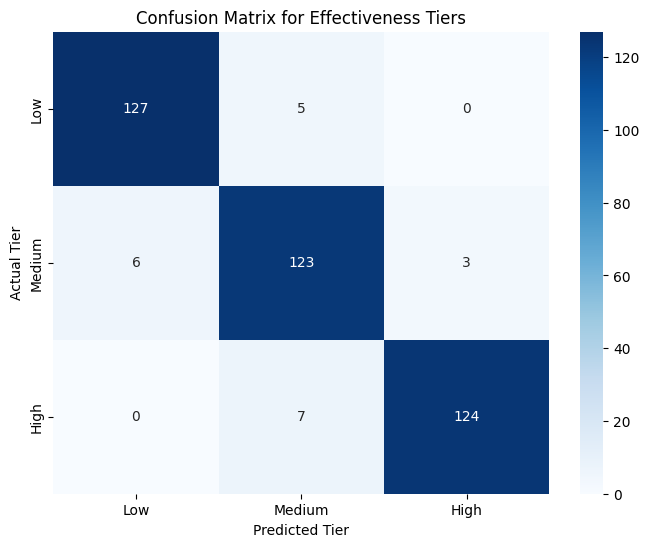

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tier_mapping.keys(), yticklabels=tier_mapping.keys())
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.title('Confusion Matrix for Effectiveness Tiers')
plt.show()